In [1]:
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# df['season'] = le.fit_transform(df['season'])
from sklearn.metrics import accuracy_score, classification_report

In [2]:
import pandas as pd

df = pd.read_csv("hospital_readmission_dataset.csv")

print(df.columns)   # check columns first

# convert date if present
if 'admission_date' in df.columns:
    df['admission_date'] = pd.to_datetime(df['admission_date'])
    df['admission_month'] = df['admission_date'].dt.month

# drop unnecessary column
df = df.drop(columns=['patient_id'], errors='ignore')

# encode categorical variables
df = pd.get_dummies(df, drop_first=True)

Index(['patient_id', 'admission_date', 'season', 'age', 'gender', 'region',
       'primary_diagnosis', 'comorbidities_count', 'length_of_stay',
       'treatment_type', 'medications_count', 'followup_visits_last_year',
       'prev_readmissions', 'insurance_type', 'discharge_disposition',
       'readmission_risk_score', 'label'],
      dtype='str')


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 37 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   admission_date                         8000 non-null   datetime64[us]
 1   age                                    8000 non-null   int64         
 2   comorbidities_count                    8000 non-null   int64         
 3   length_of_stay                         8000 non-null   int64         
 4   medications_count                      8000 non-null   int64         
 5   followup_visits_last_year              8000 non-null   int64         
 6   prev_readmissions                      8000 non-null   int64         
 7   readmission_risk_score                 8000 non-null   float64       
 8   label                                  8000 non-null   int64         
 9   admission_month                        8000 non-null   int32         
 10 

In [4]:
print(df.describe())

            admission_date          age  comorbidities_count  length_of_stay  \
count                 8000  8000.000000          8000.000000     8000.000000   
mean   2022-06-27 19:51:36    57.411625             4.318500        7.789125   
min    2021-01-01 00:00:00    18.000000             1.000000        3.000000   
25%    2021-09-26 00:00:00    46.000000             3.000000        6.000000   
50%    2022-07-01 00:00:00    57.000000             4.000000        8.000000   
75%    2023-03-23 06:00:00    69.000000             5.000000        9.000000   
max    2023-12-31 00:00:00    95.000000            10.000000       15.000000   
std                    NaN    16.724388             1.358046        1.930252   

       medications_count  followup_visits_last_year  prev_readmissions  \
count        8000.000000                8000.000000         8000.00000   
mean            7.475750                   3.638125            1.57250   
min             2.000000                   0.000000      

In [5]:
print(df.describe())

            admission_date          age  comorbidities_count  length_of_stay  \
count                 8000  8000.000000          8000.000000     8000.000000   
mean   2022-06-27 19:51:36    57.411625             4.318500        7.789125   
min    2021-01-01 00:00:00    18.000000             1.000000        3.000000   
25%    2021-09-26 00:00:00    46.000000             3.000000        6.000000   
50%    2022-07-01 00:00:00    57.000000             4.000000        8.000000   
75%    2023-03-23 06:00:00    69.000000             5.000000        9.000000   
max    2023-12-31 00:00:00    95.000000            10.000000       15.000000   
std                    NaN    16.724388             1.358046        1.930252   

       medications_count  followup_visits_last_year  prev_readmissions  \
count        8000.000000                8000.000000         8000.00000   
mean            7.475750                   3.638125            1.57250   
min             2.000000                   0.000000      

In [4]:
print(df.columns)

Index(['admission_date', 'age', 'comorbidities_count', 'length_of_stay',
       'medications_count', 'followup_visits_last_year', 'prev_readmissions',
       'readmission_risk_score', 'label', 'admission_month', 'season_Spring',
       'season_Summer', 'season_Winter', 'gender_Male', 'region_East',
       'region_North', 'region_South', 'region_West', 'primary_diagnosis_COPD',
       'primary_diagnosis_Diabetes', 'primary_diagnosis_Fracture',
       'primary_diagnosis_Heart Failure', 'primary_diagnosis_Hypertension',
       'primary_diagnosis_Influenza', 'primary_diagnosis_Kidney Disease',
       'primary_diagnosis_Pneumonia', 'primary_diagnosis_Sepsis',
       'primary_diagnosis_Stroke', 'treatment_type_Interventional',
       'treatment_type_Medical', 'treatment_type_Surgical',
       'insurance_type_Medicare', 'insurance_type_Private',
       'insurance_type_Uninsured', 'discharge_disposition_Home Health',
       'discharge_disposition_Rehab', 'discharge_disposition_Skilled Nursing'

In [6]:
print(df.columns)

Index(['admission_date', 'age', 'comorbidities_count', 'length_of_stay',
       'medications_count', 'followup_visits_last_year', 'prev_readmissions',
       'readmission_risk_score', 'label', 'admission_month', 'season_Spring',
       'season_Summer', 'season_Winter', 'gender_Male', 'region_East',
       'region_North', 'region_South', 'region_West', 'primary_diagnosis_COPD',
       'primary_diagnosis_Diabetes', 'primary_diagnosis_Fracture',
       'primary_diagnosis_Heart Failure', 'primary_diagnosis_Hypertension',
       'primary_diagnosis_Influenza', 'primary_diagnosis_Kidney Disease',
       'primary_diagnosis_Pneumonia', 'primary_diagnosis_Sepsis',
       'primary_diagnosis_Stroke', 'treatment_type_Interventional',
       'treatment_type_Medical', 'treatment_type_Surgical',
       'insurance_type_Medicare', 'insurance_type_Private',
       'insurance_type_Uninsured', 'discharge_disposition_Home Health',
       'discharge_disposition_Rehab', 'discharge_disposition_Skilled Nursing'

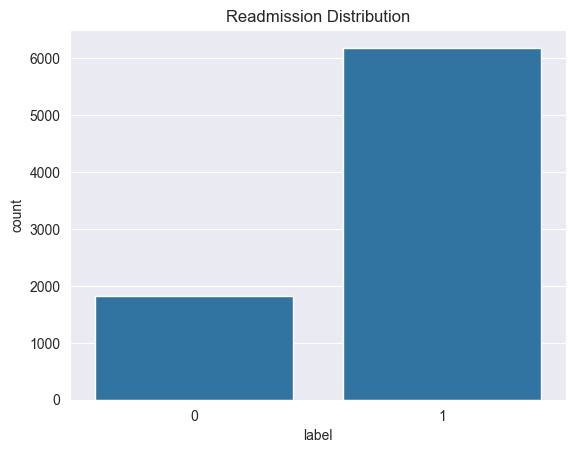

In [7]:
sns.countplot(x='label', data=df)

plt.title("Readmission Distribution")

plt.show()

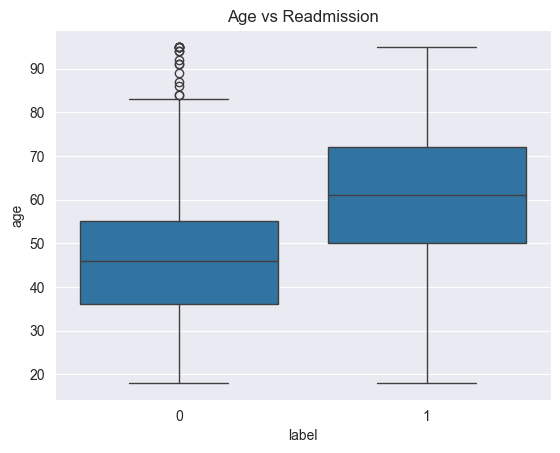

In [8]:
sns.boxplot(x='label', y='age', data=df)

plt.title("Age vs Readmission")

plt.show()

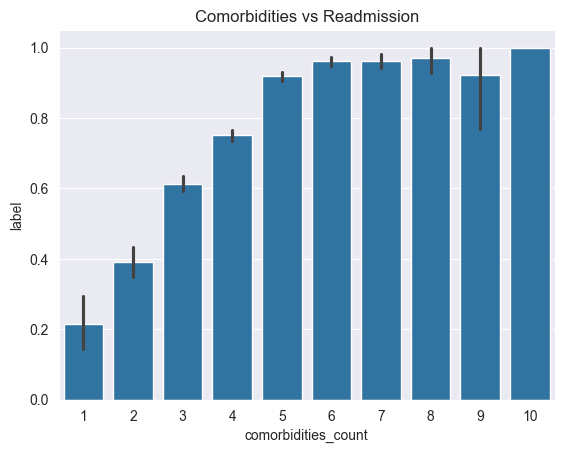

In [9]:
sns.barplot(x='comorbidities_count', y='label', data=df)

plt.title("Comorbidities vs Readmission")

plt.show()

In [10]:
df['severity_score'] = df['comorbidities_count'] + df['medications_count']

In [11]:
X = df.drop(columns=['label','admission_date'])
y = df['label']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = RandomForestClassifier()

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
print(df.columns)

Index(['admission_date', 'age', 'comorbidities_count', 'length_of_stay',
       'medications_count', 'followup_visits_last_year', 'prev_readmissions',
       'readmission_risk_score', 'label', 'admission_month', 'season_Spring',
       'season_Summer', 'season_Winter', 'gender_Male', 'region_East',
       'region_North', 'region_South', 'region_West', 'primary_diagnosis_COPD',
       'primary_diagnosis_Diabetes', 'primary_diagnosis_Fracture',
       'primary_diagnosis_Heart Failure', 'primary_diagnosis_Hypertension',
       'primary_diagnosis_Influenza', 'primary_diagnosis_Kidney Disease',
       'primary_diagnosis_Pneumonia', 'primary_diagnosis_Sepsis',
       'primary_diagnosis_Stroke', 'treatment_type_Interventional',
       'treatment_type_Medical', 'treatment_type_Surgical',
       'insurance_type_Medicare', 'insurance_type_Private',
       'insurance_type_Uninsured', 'discharge_disposition_Home Health',
       'discharge_disposition_Rehab', 'discharge_disposition_Skilled Nursing'

In [15]:
print(df.filter(like="season").head())

   season_Spring  season_Summer  season_Winter
0           True          False          False
1          False          False          False
2           True          False          False
3          False           True          False
4          False          False          False


In [16]:
pred = model.predict(X_test)
y_pred = pred  # Define y_pred for later use
print("Accuracy:",accuracy_score(y_test,pred))

print(classification_report(y_test,pred))

Accuracy: 0.814375
              precision    recall  f1-score   support

           0       0.60      0.46      0.52       351
           1       0.86      0.91      0.88      1249

    accuracy                           0.81      1600
   macro avg       0.73      0.69      0.70      1600
weighted avg       0.80      0.81      0.80      1600



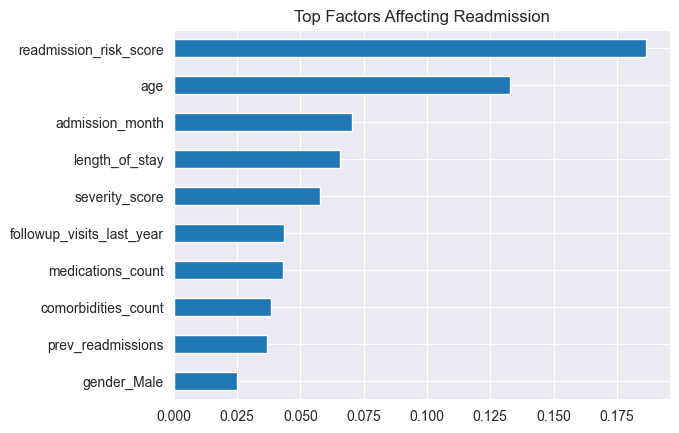

In [17]:
importances = model.feature_importances_

features = X.columns

pd.Series(importances,index=features)\
.sort_values().tail(10).plot(kind='barh')

plt.title("Top Factors Affecting Readmission")

plt.show()

In [18]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[ 161  190]
 [ 107 1142]]


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.46      0.52       351
           1       0.86      0.91      0.88      1249

    accuracy                           0.81      1600
   macro avg       0.73      0.69      0.70      1600
weighted avg       0.80      0.81      0.80      1600



In [20]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
print(feature_importance.sort_values(ascending=False).head(10))

readmission_risk_score       0.186574
age                          0.132816
admission_month              0.070264
length_of_stay               0.065572
severity_score               0.057930
followup_visits_last_year    0.043362
medications_count            0.043046
comorbidities_count          0.038277
prev_readmissions            0.036776
gender_Male                  0.024859
dtype: float64


In [21]:
RandomForestClassifier(n_estimators=300, max_depth=10)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
svm_model=SVC(probability=True)
log_model=LogisticRegression()
rf_model=RandomForestClassifier()

In [23]:
log_model.fit(X_train,y_train)
rf_model.fit(X_train,y_train)
svm_model.fit(X_train,y_train)

C:\Users\erary\OneDrive\Desktop\Healthcare\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [24]:
from sklearn.metrics import accuracy_score

models={
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "SVM": svm_model}

for name,model in models.items():
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    print(name,acc)

Logistic Regression 0.821875
Random Forest 0.81125
SVM 0.79625


In [28]:
# Create Hybrid Model

from sklearn.ensemble import VotingClassifier
hybrid_model=VotingClassifier(estimators=[('lr',log_model),('rf',rf_model),('svm',svm_model)],voting='soft')

In [29]:
hybrid_model.fit(X_train,y_train)

C:\Users\erary\OneDrive\Desktop\Healthcare\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [27]:
# Evaluate Hybrid Model

hybrid_pred = hybid_model.predict(X_test)
hybrid_accuracy = accuracy_score(y_test, hybric_pred)
print("Hybrid Model Accuracy:", hybrid_accuracy)


Hybrid Model Accuracy: 0.82125


In [37]:
def predict_patient_risk(patient_data):
    prediction=hybrid_model.predict(patient_data)
    probability=hybrid_model.predict_proba(patient_data)[0][1]

    if prediction ==1:
        risk="High Readmission Risk"
    else:
        risk="Low Readmission Risk"

    return risk,round(probability,2)

In [38]:
predict_patient_risk(X_test.iloc[0:1])

('High Readmission Risk', np.float64(0.9))

In [39]:
from lime.lime_tabular import LimeTabularExplainer

In [54]:
# Create Lime Explainer

explainer=LimeTabularExplainer(X_train.values,feature_names=X_train.columns,class_names=['No Readmission','Readmission'],mode='classification')

In [55]:
# Explain Prediction for a Single Patient

i=10

exp=explainer.explain_instance(X_test.iloc[0].values,hybrid_model.predict_proba,num_features=8)

C:\Users\erary\OneDrive\Desktop\Healthcare\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\erary\OneDrive\Desktop\Healthcare\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\erary\OneDrive\Desktop\Healthcare\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


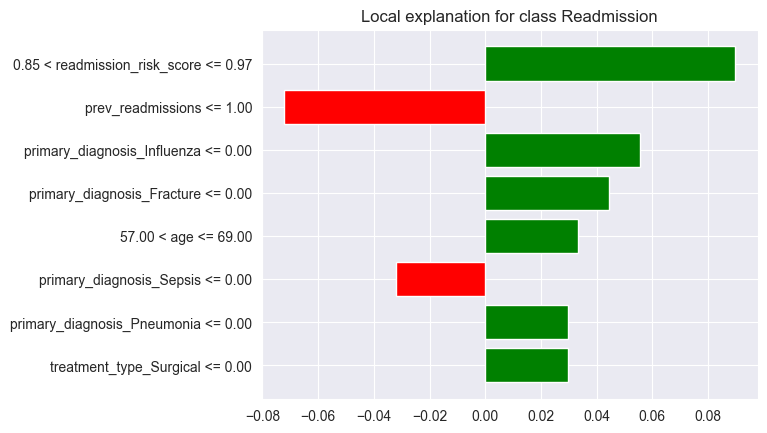

In [56]:
import matplotlib.pyplot as plt
fig=exp.as_pyplot_figure()
plt.show()

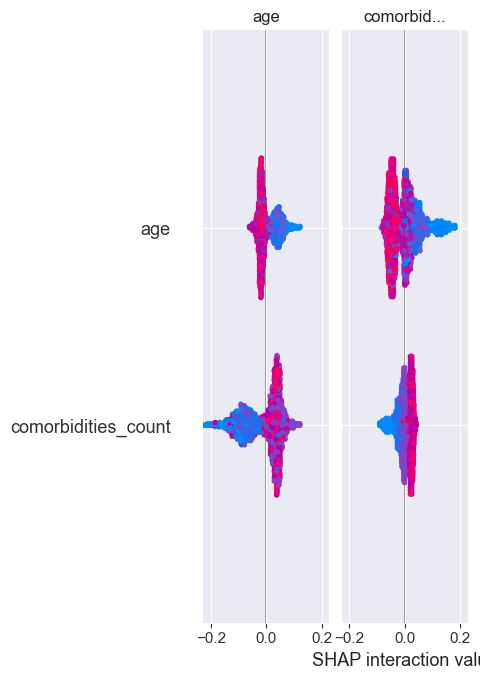

AttributeError: 'TreeExplainer' object has no attribute 'explain_instance'

In [57]:
# Compare with SHAP
import shap
explainer=shap.TreeExplainer(rf_model)
shap_values=explainer.shap_values(X_test)
shap.summary_plot(shap_values,X_test)


C:\Users\erary\OneDrive\Desktop\Healthcare\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\erary\OneDrive\Desktop\Healthcare\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\erary\OneDrive\Desktop\Healthcare\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


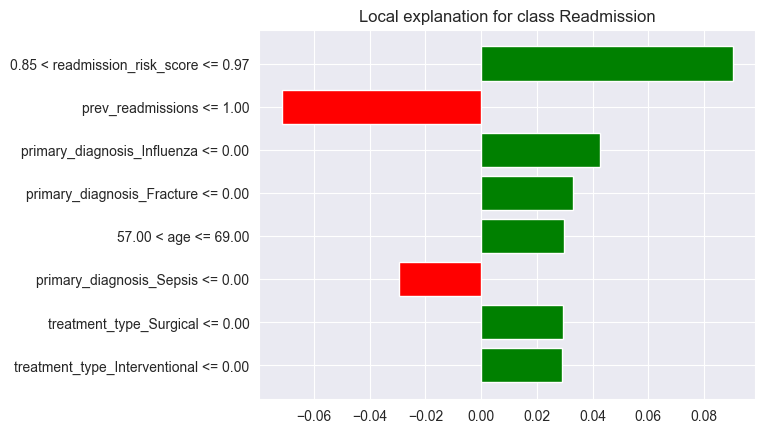

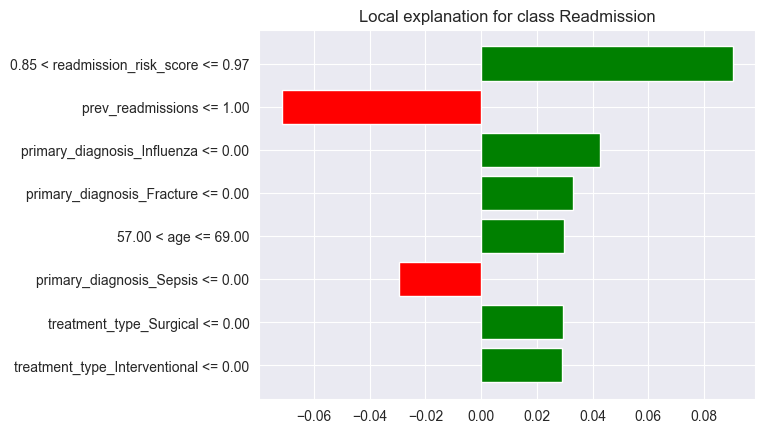

In [60]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(X_train.values, feature_names=X_train.columns, class_names=['No Readmission', 'Readmission'], mode='classification')

exp=lime_explainer.explain_instance(X_test.iloc[0].values, hybrid_model.predict_proba, num_features=8)
exp.as_pyplot_figure()


In [63]:
import joblib

joblib.dump(model,"readmission_model.pkl")
joblib.dump(list(X_train.columns),"model_columns.pkl")

['model_columns.pkl']